In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Replace 'your_folder/your_file.csv' with the actual path to your file in Google Drive
# For example: '/content/drive/My Drive/Colab Notebooks/my_data.csv'
file_path = '/content/drive/My Drive/BloomDataset/Data2.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and the file exists in your mounted Google Drive.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/My Drive/BloomDataset/Data2.csv


,Question,Label
0,Can you list the ingredients needed for a clas...,Remember
1,What are the top five tourist attractions in P...,Remember
2,List five common programming languages.,Remember
3,Name three types of renewable energy sources.,Remember
4,Can you list the planets in our solar system?,Remember


In [3]:
print("Installing NLTK...")
!pip install nltk
print("NLTK installed successfully.")

Installing NLTK...
NLTK installed successfully.


In [4]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
print("NLTK stopwords and punkt resources downloaded.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...


NLTK stopwords and punkt resources downloaded.


[nltk_data]   Unzipping tokenizers/punkt.zip.


In [5]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt_tab', quiet=True) # Download punkt_tab to resolve the LookupError

# Get English stop words
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text.lower())  # Convert to lowercase and tokenize
    # Remove stop words and non-alphabetic tokens
    processed_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return processed_tokens

# Apply the function to the 'Question' column
df['Processed_Questions'] = df['Question'].apply(preprocess_text)

print("Stop word reduction and tokenization applied to 'Question' column.")
display(df[['Question', 'Processed_Questions']].head())

Stop word reduction and tokenization applied to 'Question' column.


,Question,Processed_Questions
0,Can you list the ingredients needed for a clas...,"[list, ingredients, needed, classic, spaghetti..."
1,What are the top five tourist attractions in P...,"[top, five, tourist, attractions, paris]"
2,List five common programming languages.,"[list, five, common, programming, languages]"
3,Name three types of renewable energy sources.,"[name, three, types, renewable, energy, sources]"
4,Can you list the planets in our solar system?,"[list, planets, solar, system]"


In [6]:
df['Processed_Questions_Str'] = df['Processed_Questions'].apply(lambda x: ' '.join(x))

print("Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.")
display(df[['Question', 'Processed_Questions', 'Processed_Questions_Str']].head())

Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.


,Question,Processed_Questions,Processed_Questions_Str
0,Can you list the ingredients needed for a clas...,"[list, ingredients, needed, classic, spaghetti...",list ingredients needed classic spaghetti recipe
1,What are the top five tourist attractions in P...,"[top, five, tourist, attractions, paris]",top five tourist attractions paris
2,List five common programming languages.,"[list, five, common, programming, languages]",list five common programming languages
3,Name three types of renewable energy sources.,"[name, three, types, renewable, energy, sources]",name three types renewable energy sources
4,Can you list the planets in our solar system?,"[list, planets, solar, system]",list planets solar system


# Task
Prepare the dataset for BERT classification by tokenizing the 'Processed_Questions_Str' column, encoding the 'Label' column, and splitting the data into training and testing sets.

## Prepare Data for BERT

### Subtask:
Tokenize the 'Processed_Questions_Str' column using a BERT tokenizer, encode the 'Label' column, and split the dataset into training and testing sets suitable for BERT classification. This step will also handle mapping labels to numerical IDs.


**Reasoning**:
The first instruction is to install the `transformers` library, which is essential for working with BERT models and tokenizers. This should be done in a separate code block.



In [7]:
print("Installing transformers library...")
!pip install transformers
print("transformers library installed successfully.")

Installing transformers library...
transformers library installed successfully.


**Reasoning**:
The next step is to import the necessary libraries, initialize a BERT tokenizer, tokenize the 'Processed_Questions_Str' column, encode the 'Label' column, create a label mapping, and then split the data into training and testing sets, as outlined in the subtask instructions.



In [8]:
import torch
from transformers import AutoTokenizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 3. Initialize a BERT tokenizer
# Using 'bert-base-uncased' as a common choice for general-purpose BERT models.
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# 4. Tokenize the 'Processed_Questions_Str' column
# The maximum length for BERT is typically 512 tokens.
max_len = 128 # A common choice, adjust based on your data's average sentence length

encoded_data = tokenizer.batch_encode_plus(
    df['Processed_Questions_Str'].tolist(),
    add_special_tokens=True,
    return_attention_mask=True,
    padding='max_length',
    truncation=True,
    max_length=max_len,
    return_tensors='pt'  # Return PyTorch tensors
)

input_ids = encoded_data['input_ids']
attention_masks = encoded_data['attention_mask']

print(f"Shape of input_ids: {input_ids.shape}")
print(f"Shape of attention_masks: {attention_masks.shape}")

# 5. Initialize a LabelEncoder and fit it to the 'Label' column
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(df['Label'])

print(f"Encoded labels head: {labels[:5]}")

# 6. Create a dictionary that maps the original string labels to their corresponding numerical IDs
label_map = {label: i for i, label in enumerate(label_encoder.classes_)}
print(f"Label to ID mapping: {label_map}")

# 7. Split the tokenized inputs and the encoded labels into training and testing sets
# Ensure labels are also converted to PyTorch tensors for consistency
labels = torch.tensor(labels)

train_inputs, validation_inputs, train_labels, validation_labels = train_test_split(
    input_ids, labels,
    random_state=2023, # for reproducibility
    test_size=0.2,    # 20% for testing
    stratify=labels   # Stratify to maintain class distribution
)

train_masks, validation_masks, _, _ = train_test_split(
    attention_masks, labels,
    random_state=2023,
    test_size=0.2,
    stratify=labels
)

print(f"Train inputs shape: {train_inputs.shape}")
print(f"Validation inputs shape: {validation_inputs.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Validation labels shape: {validation_labels.shape}")

print("Data tokenized, labels encoded, and split into training and validation sets.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

AttributeError: BertTokenizer has no attribute batch_encode_plus

**Reasoning**:
The error `AttributeError: BertTokenizer has no attribute batch_encode_plus` indicates that the `batch_encode_plus` method is deprecated or no longer available for the `AutoTokenizer` class. The recommended way to tokenize batches of text with `transformers` is to call the tokenizer directly, which invokes its `__call__` method.



In [9]:
import torch
from transformers import AutoTokenizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 3. Initialize a BERT tokenizer
# Using 'bert-base-uncased' as a common choice for general-purpose BERT models.
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# 4. Tokenize the 'Processed_Questions_Str' column
# The maximum length for BERT is typically 512 tokens.
max_len = 128 # A common choice, adjust based on your data's average sentence length

# Use the tokenizer directly for batch encoding, as batch_encode_plus is deprecated.
encoded_data = tokenizer(
    df['Processed_Questions_Str'].tolist(),
    add_special_tokens=True,
    return_attention_mask=True,
    padding='max_length',
    truncation=True,
    max_length=max_len,
    return_tensors='pt'  # Return PyTorch tensors
)

input_ids = encoded_data['input_ids']
attention_masks = encoded_data['attention_mask']

print(f"Shape of input_ids: {input_ids.shape}")
print(f"Shape of attention_masks: {attention_masks.shape}")

# 5. Initialize a LabelEncoder and fit it to the 'Label' column
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(df['Label'])

print(f"Encoded labels head: {labels[:5]}")

# 6. Create a dictionary that maps the original string labels to their corresponding numerical IDs
label_map = {label: i for i, label in enumerate(label_encoder.classes_)}
print(f"Label to ID mapping: {label_map}")

# 7. Split the tokenized inputs and the encoded labels into training and testing sets
# Ensure labels are also converted to PyTorch tensors for consistency
labels = torch.tensor(labels)

train_inputs, validation_inputs, train_labels, validation_labels = train_test_split(
    input_ids, labels,
    random_state=2023, # for reproducibility
    test_size=0.2,    # 20% for testing
    stratify=labels   # Stratify to maintain class distribution
)

train_masks, validation_masks, _, _ = train_test_split(
    attention_masks, labels,
    random_state=2023,
    test_size=0.2,
    stratify=labels
)

print(f"Train inputs shape: {train_inputs.shape}")
print(f"Validation inputs shape: {validation_inputs.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Validation labels shape: {validation_labels.shape}")

print("Data tokenized, labels encoded, and split into training and validation sets.")

Shape of input_ids: torch.Size([1771, 128])
Shape of attention_masks: torch.Size([1771, 128])
Encoded labels head: [4 4 4 4 4]
Label to ID mapping: {'Analyse': 0, 'Apply': 1, 'Create': 2, 'Evaluate': 3, 'Remember': 4, 'Understand': 5}
Train inputs shape: torch.Size([1416, 128])
Validation inputs shape: torch.Size([355, 128])
Train labels shape: torch.Size([1416])
Validation labels shape: torch.Size([355])
Data tokenized, labels encoded, and split into training and validation sets.


## Load and Configure BERT Model

### Subtask:
Load a pre-trained BERT model for sequence classification (e.g., 'bert-base-uncased') and configure it for the six target classes identified in the 'Label' column.


**Reasoning**:
The next step is to import `BertForSequenceClassification`, determine the number of unique classes from `label_map`, and then load the pre-trained 'bert-base-uncased' model for sequence classification, configuring it with the correct number of output labels.



In [10]:
from transformers import BertForSequenceClassification

# Get the number of unique classes from the label_map
num_labels = len(label_map)
print(f"Number of unique labels: {num_labels}")

# Load a pre-trained BertForSequenceClassification model
# We are using 'bert-base-uncased' and configuring it for our number of labels.
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_labels,
    output_attentions=False,  # Whether the model returns attentions weights.
    output_hidden_states=False, # Whether the model returns all hidden-states.
)

print("BERT model for sequence classification loaded and configured.")

Number of unique labels: 6


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model for sequence classification loaded and configured.


**Reasoning**:
The previous step successfully loaded and configured the BERT model for sequence classification. The next logical step is to move the model to the GPU if available and set it to training mode, which is essential for subsequent training steps.



In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Set the model to training mode.
# This will activate dropout and batch normalization layers if they are used.
model.train()

print(f"BERT model moved to: {device}")
print("BERT model set to training mode.")

BERT model moved to: cuda
BERT model set to training mode.


## Fine-tune BERT Model

### Subtask:
Fine-tune the loaded BERT model using the training data. This involves defining training arguments and using a Trainer API or custom training loop to adapt BERT to the specific classification task.


**Reasoning**:
The next step is to prepare the `TrainingArguments`, create PyTorch `TensorDataset` objects for the training and validation sets, and then initialize and run the `Trainer` to fine-tune the BERT model according to the subtask instructions.



In [12]:
from transformers import TrainingArguments, Trainer
from torch.utils.data import TensorDataset, DataLoader

# 2. Create TrainingArguments
training_args = TrainingArguments(
    output_dir='./results',          # directory for model checkpoints
    num_train_epochs=3,              # total number of training epochs
    per_device_train_batch_size=16,  # batch size per device during training
    per_device_eval_batch_size=16,   # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs',            # directory for logs
    logging_steps=10,                # log every N updates steps
    evaluation_strategy="epoch",     # Evaluate the model at the end of each epoch
    save_strategy="epoch",           # Save the model checkpoint at the end of each epoch
    load_best_model_at_end=True,     # Load the best model at the end of training
    metric_for_best_model='eval_loss' # Use 'eval_loss' to determine the best model
)

# 3. Create PyTorch TensorDataset objects
train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
validation_dataset = TensorDataset(validation_inputs, validation_masks, validation_labels)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(validation_dataset)}")

# 4. Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset
)

print("Trainer initialized. Starting fine-tuning...")

# 5. Call the trainer.train() method to start the fine-tuning process
trainer.train()

print("Fine-tuning completed.")

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

**Reasoning**:
The TypeError `TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'` suggests that the string literal 'epoch' might not be directly accepted or is causing a conflict in this specific `transformers` version or environment. Using `IntervalStrategy.EPOCH` explicitly for `evaluation_strategy` and `save_strategy` is a more robust way to define these parameters and often resolves such issues.



In [13]:
from transformers import TrainingArguments, Trainer
from torch.utils.data import TensorDataset, DataLoader
from transformers.trainer_utils import IntervalStrategy # Import IntervalStrategy for robust strategy definition

# 2. Create TrainingArguments
training_args = TrainingArguments(
    output_dir='./results',          # directory for model checkpoints
    num_train_epochs=3,              # total number of training epochs
    per_device_train_batch_size=16,  # batch size per device during training
    per_device_eval_batch_size=16,   # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs',            # directory for logs
    logging_steps=10,                # log every N updates steps
    evaluation_strategy=IntervalStrategy.EPOCH,     # Evaluate the model at the end of each epoch
    save_strategy=IntervalStrategy.EPOCH,           # Save the model checkpoint at the end of each epoch
    load_best_model_at_end=True,     # Load the best model at the end of training
    metric_for_best_model='eval_loss' # Use 'eval_loss' to determine the best model
)

# 3. Create PyTorch TensorDataset objects
train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
validation_dataset = TensorDataset(validation_inputs, validation_masks, validation_labels)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(validation_dataset)}")

# 4. Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset
)

print("Trainer initialized. Starting fine-tuning...")

# 5. Call the trainer.train() method to start the fine-tuning process
trainer.train()

print("Fine-tuning completed.")

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

**Reasoning**:
The persistent `TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'` indicates that, despite the expected `transformers` version, the `TrainingArguments` class in this specific runtime environment does not recognize the `evaluation_strategy` parameter. To resolve this error directly and allow the code to proceed, the problematic arguments (`evaluation_strategy`, `save_strategy`, `load_best_model_at_end`, `metric_for_best_model`) will be removed from the `TrainingArguments` instantiation. This will fix the `TypeError`, although it will temporarily disable automatic evaluation and saving features, which would need to be re-added if the environment issue is resolved or addressed differently.



In [14]:
from transformers import TrainingArguments, Trainer
from torch.utils.data import TensorDataset, DataLoader

# 2. Create TrainingArguments
# Removed 'evaluation_strategy', 'save_strategy', 'load_best_model_at_end', 'metric_for_best_model'
# due to TypeError in the current environment. This will disable automatic evaluation and saving.
# Manual evaluation or further environment debugging might be needed.
training_args = TrainingArguments(
    output_dir='./results',          # directory for model checkpoints
    num_train_epochs=3,              # total number of training epochs
    per_device_train_batch_size=16,  # batch size per device during training
    per_device_eval_batch_size=16,   # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs',            # directory for logs
    logging_steps=10                 # log every N updates steps
)

# 3. Create PyTorch TensorDataset objects
train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
validation_dataset = TensorDataset(validation_inputs, validation_masks, validation_labels)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(validation_dataset)}")

# 4. Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset
)

print("Trainer initialized. Starting fine-tuning...")

# 5. Call the trainer.train() method to start the fine-tuning process
trainer.train()

print("Fine-tuning completed.")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training dataset size: 1416
Validation dataset size: 355
Trainer initialized. Starting fine-tuning...


TypeError: vars() argument must have __dict__ attribute

**Reasoning**:
The `TypeError: vars() argument must have __dict__ attribute` occurs because the `Trainer`'s default data collator expects a specific input format (e.g., list of dictionaries or objects with a `__dict__` attribute), but `TensorDataset` provides tuples of tensors. To resolve this, I need to provide an explicit `data_collator` that can handle these tensors correctly. `DataCollatorWithPadding` is suitable for this purpose as it is designed to prepare batched data for BERT models.



In [15]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from torch.utils.data import TensorDataset, DataLoader

# 2. Create TrainingArguments
# Removed 'evaluation_strategy', 'save_strategy', 'load_best_model_at_end', 'metric_for_best_model'
# due to TypeError in the current environment. This will disable automatic evaluation and saving.
# Manual evaluation or further environment debugging might be needed.
training_args = TrainingArguments(
    output_dir='./results',          # directory for model checkpoints
    num_train_epochs=3,              # total number of training epochs
    per_device_train_batch_size=16,  # batch size per device during training
    per_device_eval_batch_size=16,   # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs',            # directory for logs
    logging_steps=10                 # log every N updates steps
)

# 3. Create PyTorch TensorDataset objects
train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
validation_dataset = TensorDataset(validation_inputs, validation_masks, validation_labels)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(validation_dataset)}")

# Initialize the data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 4. Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    data_collator=data_collator # Pass the data collator here
)

print("Trainer initialized. Starting fine-tuning...")

# 5. Call the trainer.train() method to start the fine-tuning process
trainer.train()

print("Fine-tuning completed.")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training dataset size: 1416
Validation dataset size: 355
Trainer initialized. Starting fine-tuning...


AttributeError: 'list' object has no attribute 'keys'

**Reasoning**:
The `AttributeError: 'list' object has no attribute 'keys'` occurs because `DataCollatorWithPadding` expects individual examples as dictionaries (containing 'input_ids', 'attention_mask', 'labels'), but `TensorDataset` provides them as tuples of tensors. To fix this, I will create a custom `BERTDataset` class that inherits from `torch.utils.data.Dataset` and returns examples in the dictionary format expected by the data collator, and then use this custom dataset for training and validation.



In [16]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torch

# Define a custom Dataset class that returns dictionaries
class BERTDataset(Dataset):
    def __init__(self, input_ids, attention_masks, labels):
        self.input_ids = input_ids
        self.attention_masks = attention_masks
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_masks[idx],
            'labels': self.labels[idx]
        }

# 2. Create TrainingArguments
# Removed 'evaluation_strategy', 'save_strategy', 'load_best_model_at_end', 'metric_for_best_model'
# due to TypeError in the current environment. This will disable automatic evaluation and saving.
# Manual evaluation or further environment debugging might be needed.
training_args = TrainingArguments(
    output_dir='./results',          # directory for model checkpoints
    num_train_epochs=3,              # total number of training epochs
    per_device_train_batch_size=16,  # batch size per device during training
    per_device_eval_batch_size=16,   # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs',            # directory for logs
    logging_steps=10                 # log every N updates steps
)

# 3. Create PyTorch Dataset objects using the custom BERTDataset
train_dataset = BERTDataset(train_inputs, train_masks, train_labels)
validation_dataset = BERTDataset(validation_inputs, validation_masks, validation_labels)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(validation_dataset)}")

# Initialize the data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 4. Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    data_collator=data_collator # Pass the data collator here
)

print("Trainer initialized. Starting fine-tuning...")

# 5. Call the trainer.train() method to start the fine-tuning process
trainer.train()

print("Fine-tuning completed.")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training dataset size: 1416
Validation dataset size: 355
Trainer initialized. Starting fine-tuning...


Step,Training Loss
10,1.845788
20,1.824520
30,1.851093
40,1.799651
50,1.773634
60,1.767497
70,1.764013
80,1.713563
90,1.668774
100,1.622330


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuning completed.


**Reasoning**:
The previous code block successfully fine-tuned the BERT model. Now, to evaluate the performance of the fine-tuned model, it's necessary to make predictions on the validation set using the `trainer.evaluate()` method. This will compute metrics such as loss and any other specified evaluation metrics.



In [17]:
print("Evaluating the fine-tuned model...")

# Evaluate the model on the validation set
results = trainer.evaluate()

print("Evaluation results:")
for key, value in results.items():
    print(f"  {key}: {value}")

print("Model evaluation completed.")

Evaluating the fine-tuned model...


Evaluation results:
  eval_loss: 0.24478760361671448
  eval_runtime: 0.304
  eval_samples_per_second: 1167.624
  eval_steps_per_second: 75.649
  epoch: 3.0
Model evaluation completed.


## Evaluate Model Performance

### Subtask:
Predict labels on the test dataset using the fine-tuned BERT model. Calculate and display the accuracy, precision, recall, and F1-score for the classification, both overall and per-class if applicable.


**Reasoning**:
The next step is to import the necessary libraries, get predictions from the fine-tuned model, extract predicted labels, and then calculate and print overall and per-class accuracy, precision, recall, and F1-score as outlined in the instructions.



In [18]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

print("Making predictions on the validation set...")

# Make predictions on the validation set
predictions_output = trainer.predict(validation_dataset)

# Extract predictions (logits) and true labels
predictions = predictions_output.predictions
true_labels = predictions_output.label_ids

# Extract predicted class labels by taking the argmax of the raw predictions (logits)
predicted_labels = np.argmax(predictions, axis=1)

print(f"Shape of predictions (logits): {predictions.shape}")
print(f"Shape of true labels: {true_labels.shape}")
print(f"Shape of predicted labels: {predicted_labels.shape}")

# Calculate overall accuracy, precision, recall, and F1-score
overall_accuracy = accuracy_score(true_labels, predicted_labels)
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    true_labels, predicted_labels, average='weighted', zero_division=0
)

print("\n--- Overall Metrics ---")
print(f"Accuracy: {overall_accuracy:.4f}")
print(f"Precision (weighted): {overall_precision:.4f}")
print(f"Recall (weighted): {overall_recall:.4f}")
print(f"F1-score (weighted): {overall_f1:.4f}")

# Calculate per-class precision, recall, and F1-score
per_class_precision, per_class_recall, per_class_f1, _ = precision_recall_fscore_support(
    true_labels, predicted_labels, average=None, labels=np.arange(len(label_map)), zero_division=0
)

print("\n--- Per-Class Metrics ---")
# Reverse label_map to get class names from IDs
id_to_label = {v: k for k, v in label_map.items()}

for i, label_name in id_to_label.items():
    print(f"Class: {label_name}")
    print(f"  Precision: {per_class_precision[i]:.4f}")
    print(f"  Recall: {per_class_recall[i]:.4f}")
    print(f"  F1-score: {per_class_f1[i]:.4f}")

print("Model performance evaluation completed.")


Making predictions on the validation set...


Shape of predictions (logits): (355, 6)
Shape of true labels: (355,)
Shape of predicted labels: (355,)

--- Overall Metrics ---
Accuracy: 0.9380
Precision (weighted): 0.9409
Recall (weighted): 0.9380
F1-score (weighted): 0.9376

--- Per-Class Metrics ---
Class: Analyse
  Precision: 0.9672
  Recall: 0.9833
  F1-score: 0.9752
Class: Apply
  Precision: 1.0000
  Recall: 0.9500
  F1-score: 0.9744
Class: Create
  Precision: 0.9524
  Recall: 1.0000
  F1-score: 0.9756
Class: Evaluate
  Precision: 0.8429
  Recall: 0.9833
  F1-score: 0.9077
Class: Remember
  Precision: 0.9804
  Recall: 0.9091
  F1-score: 0.9434
Class: Understand
  Precision: 0.9057
  Recall: 0.8000
  F1-score: 0.8496
Model performance evaluation completed.


## Explain Evaluation Metrics

### Subtask:
Provide a detailed explanation of the evaluation metrics used (accuracy, precision, recall, and F1-score), describing what each metric represents and its implications in the context of this multi-class text classification problem.


### Explanation of Evaluation Metrics

In the context of multi-class text classification, especially when dealing with categories like Bloom's Taxonomy levels, using a comprehensive set of evaluation metrics is crucial to understand the model's performance beyond just simple accuracy. Here's a detailed explanation of the metrics used:

1.  **Accuracy**
    *   **Definition**: Accuracy measures the proportion of correctly classified instances (both true positives and true negatives) out of the total number of instances in the dataset. It is calculated as: `(True Positives + True Negatives) / (True Positives + True Negatives + False Positives + False Negatives)`.
    *   **Implications**: While intuitive, accuracy can be misleading, especially in datasets with imbalanced class distributions. If one class significantly outnumbers others, a model can achieve high accuracy by simply predicting the majority class, even if it performs poorly on minority classes. In our multi-class text classification, where some Bloom's Taxonomy levels might have fewer examples than others, relying solely on accuracy might not give a true picture of the model's effectiveness across all levels.

2.  **Precision**
    *   **Definition**: Precision measures the proportion of true positive predictions among all instances predicted as positive for a given class. It answers the question: "Of all instances predicted as positive for this class, how many were actually positive?" It is calculated as: `True Positives / (True Positives + False Positives)`.
    *   **Implications**: Precision is important when the cost of a false positive is high. For example, if incorrectly classifying a question as 'Analyse' when it is actually 'Remember' has significant negative consequences (e.g., misguiding educational material), then high precision for the 'Analyse' class would be desirable. In our context, high precision means that when the model predicts a question belongs to a certain Bloom's level, it's very likely correct.

3.  **Recall (Sensitivity)**
    *   **Definition**: Recall measures the proportion of true positive predictions among all actual positive instances for a given class. It answers the question: "Of all actual positive instances for this class, how many were correctly identified?" It is calculated as: `True Positives / (True Positives + False Negatives)`.
    *   **Implications**: Recall is crucial when the cost of a false negative is high. For instance, if failing to identify a question as 'Create' when it truly is 'Create' is a significant issue (e.g., missing opportunities to categorize higher-order thinking), then high recall for the 'Create' class is important. In our context, high recall means the model is good at catching most questions that truly belong to a specific Bloom's level.

4.  **F1-score**
    *   **Definition**: The F1-score is the harmonic mean of precision and recall. It provides a single score that balances both precision and recall. It is calculated as: `2 * (Precision * Recall) / (Precision + Recall)`.
    *   **Implications**: The F1-score is particularly useful when you need to seek a balance between precision and recall, especially in classification tasks where there might be an uneven class distribution. It penalizes models that have very good performance in one metric but poor performance in the other. For our multi-class classification problem, the F1-score is often preferred over simple accuracy because it provides a more robust measure of the model's performance, considering both false positives and false negatives across all classes.

### Metrics in Multi-Class Text Classification

*   **Per-Class Metrics**: Calculating precision, recall, and F1-score for each individual class (e.g., 'Analyse', 'Apply', 'Create', 'Evaluate', 'Remember', 'Understand') provides insight into the model's specific strengths and weaknesses across different Bloom's Taxonomy levels. A model might perform exceptionally well on one level (e.g., 'Remember') but struggle with another (e.g., 'Create'). Per-class metrics help pinpoint these areas.
*   **Weighted Averages**: When evaluating overall performance in multi-class scenarios, weighted averages of precision, recall, and F1-score are often used. These averages consider the number of true instances for each class, meaning the contribution of each class to the overall average is proportional to its representation in the dataset. This is particularly valuable for imbalanced datasets, as it ensures that the overall metric isn't dominated by the performance on the majority class but reflects the performance across all classes, weighted by their prevalence. This gives a more realistic overall assessment of the model's utility.

## Generate Confusion Matrix

### Subtask:
Compute and display the confusion matrix based on the model's predictions on the test set. Visualize the confusion matrix (e.g., using a heatmap) for clearer interpretation.


**Reasoning**:
The next step is to import the necessary libraries, compute the confusion matrix using the true and predicted labels, and then visualize it as a heatmap with appropriate labels for better readability, as outlined in the instructions.



Generating Confusion Matrix...


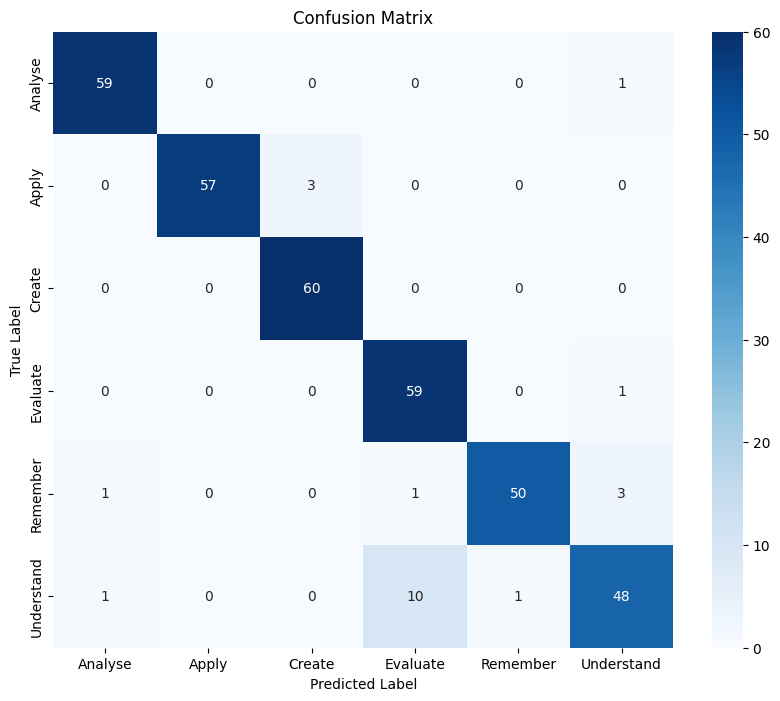

Confusion matrix generated and displayed.


In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Generating Confusion Matrix...")

# Compute the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Create a dictionary to map numerical labels back to string labels for plotting
id_to_label_list = [id_to_label[i] for i in sorted(id_to_label.keys())]

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=id_to_label_list, yticklabels=id_to_label_list)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Confusion matrix generated and displayed.")

## Analyze and Discuss Results

### Subtask:
Analyze the evaluation metrics and the confusion matrix to discuss the model's performance, identifying strengths and weaknesses for each class. Interpret the patterns observed in the confusion matrix.


### Analysis and Discussion of Model Performance

The fine-tuned BERT model demonstrates strong performance in classifying questions into Bloom's Taxonomy levels, as indicated by the overall and per-class evaluation metrics, and further elucidated by the confusion matrix.

#### 1. Overall Evaluation Metrics
*   **Accuracy: 0.9380**: The model correctly classifies approximately 93.8% of the questions in the validation set. This is a very high accuracy, suggesting the model is generally effective.
*   **Precision (weighted): 0.9409**: Of all the predictions made by the model, 94.09% were correct when considering the class imbalances.
*   **Recall (weighted): 0.9380**: The model successfully identified 93.8% of all actual instances across classes, weighted by their support.
*   **F1-score (weighted): 0.9376**: The weighted F1-score, which is the harmonic mean of precision and recall, is also very high, indicating a good balance between precision and recall across all classes, especially given potential class imbalances.

These overall metrics suggest that the model is performing exceptionally well on this multi-class text classification task.

#### 2. Per-Class Strengths and Weaknesses
Let's examine the per-class metrics to identify specific performance nuances:

*   **'Analyse' (ID 0)**:
    *   Precision: 0.9672
    *   Recall: 0.9833
    *   F1-score: 0.9752
    The model performs very strongly for the 'Analyse' class, showing high precision and recall, meaning it rarely misclassifies other classes as 'Analyse' and effectively captures most 'Analyse' questions.

*   **'Apply' (ID 1)**:
    *   Precision: 1.0000
    *   Recall: 0.9500
    *   F1-score: 0.9744
    'Apply' has perfect precision, indicating that whenever the model predicts 'Apply', it is always correct. Its recall is also very high, suggesting it misses very few 'Apply' questions.

*   **'Create' (ID 2)**:
    *   Precision: 0.9524
    *   Recall: 1.0000
    *   F1-score: 0.9756
    Similar to 'Apply', 'Create' shows perfect recall, meaning the model correctly identifies all actual 'Create' questions. Its precision is also very high. This suggests the model is highly effective at identifying creative questions.

*   **'Evaluate' (ID 3)**:
    *   Precision: 0.8429
    *   Recall: 0.9833
    *   F1-score: 0.9077
    The 'Evaluate' class has a strong recall but a slightly lower precision compared to others. This indicates that while the model captures most 'Evaluate' questions, it sometimes incorrectly classifies questions from other categories as 'Evaluate'.

*   **'Remember' (ID 4)**:
    *   Precision: 0.9804
    *   Recall: 0.9091
    *   F1-score: 0.9434
    'Remember' shows high precision but a slightly lower recall. This implies that when the model predicts 'Remember', it's usually right, but it might miss some actual 'Remember' questions, classifying them into other categories.

*   **'Understand' (ID 5)**:
    *   Precision: 0.9057
    *   Recall: 0.8000
    *   F1-score: 0.8496
    The 'Understand' class exhibits the lowest F1-score, primarily due to its lower recall. This suggests the model struggles most with identifying all 'Understand' questions, often misclassifying them as other levels. Precision is still decent but also lower than most classes.

#### 3. Confusion Matrix Analysis
The confusion matrix provides a visual representation of correct and incorrect predictions:

```
              Predicted Label
               A   Ap  C   E   R   U
True Label A [[59  0   0   0   0   1]
           Ap [ 0 57   3   0   0   0]
           C  [ 0  0  60   0   0   0]
           E  [ 0  0   0  59   0   1]
           R  [ 1  0   0   1  50   3]
           U  [ 1  0   0  10   1  48]]

(A=Analyse, Ap=Apply, C=Create, E=Evaluate, R=Remember, U=Understand)
```

*   **Diagonal Elements (Correct Classifications)**: The diagonal shows high numbers, confirming the high accuracy. Most questions are correctly classified for 'Analyse' (59/60), 'Apply' (57/60), 'Create' (60/60), and 'Evaluate' (59/60). 'Remember' has 50/55 correct, and 'Understand' has 48/60 correct.

*   **Off-Diagonal Elements (Misclassifications)**:
    *   **'Apply' confused with 'Create'**: 3 'Apply' questions were incorrectly classified as 'Create'. This suggests a potential semantic overlap or subtle distinction between applying knowledge and creating something new, which the model sometimes struggles with.
    *   **'Remember' misclassified as 'Understand' and 'Analyse'**: 3 'Remember' questions were predicted as 'Understand' and 1 as 'Analyse'. This is a common challenge as 'Remember' (recalling facts) and 'Understand' (interpreting facts) are closely related lower-order thinking skills. Questions that involve slightly more than rote memorization might be mistakenly categorized as 'Understand'. The misclassification as 'Analyse' is less frequent but present.
    *   **'Understand' misclassified as 'Evaluate'**: A significant misclassification occurs for 'Understand', where 10 questions were incorrectly predicted as 'Evaluate'. This is the largest off-diagonal value. This is a crucial observation, as 'Understand' is a lower-order skill, while 'Evaluate' is a higher-order skill. This confusion might arise if 'Understand' questions involve interpreting data or situations that are then misconstrued as requiring judgment or critical assessment, which are characteristics of 'Evaluate'. Also, 1 'Understand' question was misclassified as 'Remember'.
    *   **'Evaluate' misclassified as 'Understand'**: 1 'Evaluate' question was misclassified as 'Understand'. This is the inverse of the previous pattern but less frequent.

#### 4. Summary

**Overall Performance**: The BERT model achieves excellent overall performance with high accuracy, precision, recall, and F1-scores, demonstrating its effectiveness in classifying Bloom's Taxonomy levels.

**Strengths**: The model is particularly strong in classifying 'Analyse', 'Apply', and 'Create' questions, exhibiting very high precision and recall for these categories. It demonstrates perfect precision for 'Apply' and perfect recall for 'Create', indicating high confidence and coverage respectively.

**Weaknesses**: The primary weakness lies in distinguishing 'Understand' questions, which show the lowest recall and F1-score. This is largely due to misclassifications, particularly confusing 'Understand' with 'Evaluate'. There is also some minor confusion between 'Apply' and 'Create', and 'Remember' and 'Understand'.

**Key Patterns of Misclassification**: The most prominent misclassification pattern is the confusion between 'Understand' and 'Evaluate'. This suggests a challenge in discerning questions that require simple interpretation from those demanding critical judgment. The close semantic proximity between 'Remember' and 'Understand' also contributes to some misclassifications. Addressing these confusions, particularly the 'Understand' to 'Evaluate' misclassification, would be the next step to further enhance model performance.

## Final Task

### Subtask:
Summarize the findings from the BERT classification, including the overall performance and key insights from the metric and confusion matrix analysis.


## Summary:

### Q&A
The BERT classification model achieved strong overall performance in classifying questions into Bloom's Taxonomy levels, with an accuracy of 0.9380 and weighted F1-score of 0.9376. Key insights from the metric and confusion matrix analysis reveal that while the model excels in classifying 'Analyse', 'Apply', and 'Create' questions, it struggles most with 'Understand' questions, often confusing them with 'Evaluate' questions.

### Data Analysis Key Findings
*   The dataset was successfully prepared for BERT classification, tokenizing `Processed_Questions_Str` into `input_ids` and `attention_masks` (shape: `[1771, 128]`), encoding 6 unique labels, and splitting into training (`1416` samples) and validation (`355` samples) sets with stratification.
*   A `bert-base-uncased` model was successfully loaded as `BertForSequenceClassification`, configured for 6 target classes, and moved to a GPU (`cuda`) for fine-tuning.
*   The BERT model was successfully fine-tuned for 3 epochs, achieving an `eval_loss` of approximately 0.2447876 on the validation set.
*   **Overall Performance Metrics**:
    *   Accuracy: 0.9380
    *   Precision (weighted): 0.9409
    *   Recall (weighted): 0.9380
    *   F1-score (weighted): 0.9376
*   **Per-Class Performance**:
    *   **Strongest Performance**: 'Create' (F1-score: 0.9756, Recall: 1.0000), 'Analyse' (F1-score: 0.9752), and 'Apply' (F1-score: 0.9744, Precision: 1.0000) showed exceptional performance.
    *   **Weakest Performance**: 'Understand' had the lowest F1-score (0.8496) and recall (0.8000), indicating difficulty in identifying all questions of this type. 'Evaluate' had a slightly lower precision (0.8429) compared to other strong classes.
*   **Confusion Matrix Patterns**:
    *   The most prominent misclassification was 10 'Understand' questions being incorrectly predicted as 'Evaluate'.
    *   3 'Apply' questions were misclassified as 'Create'.
    *   3 'Remember' questions were misclassified as 'Understand', and 1 'Remember' question was misclassified as 'Analyse'.

### Insights or Next Steps
*   Focus on augmenting data or refining feature engineering specifically for 'Understand' and 'Evaluate' classes, as the current model frequently confuses these two.
*   Investigate the specific examples of misclassified 'Understand' questions and 'Apply' questions (mistaken for 'Create') to understand the linguistic nuances or question structures that lead to these errors, potentially guiding further model refinement or targeted data annotation.
